# Taller de Álgebra Lineal: Análisis Inmobiliario en Rionegro

## 1. Generación del Dataset
A continuación, se generan los datos simulados basados en las características reales de los sectores de Rionegro.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Configuración de estilo profesional para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


# Configuración inicial
np.random.seed(42)
n_registros = 54700

# ── DICCIONARIO MAESTRO BASADO EN EL PDF (CON VARIABLES NUMÉRICAS) ────────────
# Se definen los valores de metro cuadrado por estrato y las clasificaciones numéricas.
sectores_info = {
    'Comuna 1 (Centro Histórico)': {
        'estratos': [2, 3, 4],
        'precio_m2_estrato': {2: 3_500_000, 3: 4_100_000, 4: 4_800_000},
        'area_mean': 134.8, 'area_std': 25.0, 'dist': 1.5,
        'tipo_num': 1, 'conj_num': 0, 'topo_num': 0, 'parq_num': 0
    },
    'Comuna 2 (San Antonio)': {
        'estratos': [3, 4, 5],
        'precio_m2_estrato': {3: 4_500_000, 4: 4_900_000, 5: 5_500_000},
        'area_mean': 146.5, 'area_std': 28.0, 'dist': 3.5,
        'tipo_num': 1, 'conj_num': 0, 'topo_num': 0, 'parq_num': 1
    },
    'Comuna 3 (Uribe Jaramillo)': {
        'estratos': [2, 3],
        'precio_m2_estrato': {2: 5_000_000, 3: 6_000_000},
        'area_mean': 106.45, 'area_std': 20.0, 'dist': 12.0,
        'tipo_num': 1, 'conj_num': 0, 'topo_num': 1, 'parq_num': 1
    },
    'Comuna 4 (El Porvenir)': {
        'estratos': [3, 4],
        'precio_m2_estrato': {3: 4_600_000, 4: 5_200_000},
        'area_mean': 157.27, 'area_std': 30.0, 'dist': 2.5,
        'tipo_num': 1, 'conj_num': 1, 'topo_num': 0, 'parq_num': 1
    },
    'Corregimiento Occidente (Llanogrande)': {
        'estratos': [5, 6],
        'precio_m2_estrato': {5: 7_200_000, 6: 8_500_000},
        'area_mean': 546.86, 'area_std': 120.0, 'dist': 12.0,
        'tipo_num': 0, 'conj_num': 1, 'topo_num': 1, 'parq_num': 1
    },
    'Corregimiento Sur (Cabeceras)': {
        'estratos': [4, 5, 6],
        'precio_m2_estrato': {4: 10_000_000, 5: 12_000_000, 6: 14_000_000},
        'area_mean': 327.6, 'area_std': 80.0, 'dist': 14.0,
        'tipo_num': 0, 'conj_num': 1, 'topo_num': 2, 'parq_num': 1
    },
    'Corregimiento Norte (Galicia/La Mosca)': {
        'estratos': [2, 3, 4],
        'precio_m2_estrato': {2: 6_500_000, 3: 7_600_000, 4: 8_500_000},
        'area_mean': 213.0, 'area_std': 45.0, 'dist': 10.0,
        'tipo_num': 0, 'conj_num': 0, 'topo_num': 3, 'parq_num': 1
    },
    'Corregimiento Centro (Río Abajo)': {
        'estratos': [3, 4],
        'precio_m2_estrato': {3: 1_200_000, 4: 1_600_000},
        'area_mean': 1135.0, 'area_std': 250.0, 'dist': 6.0,
        'tipo_num': 0, 'conj_num': 0, 'topo_num': 2, 'parq_num': 1
    }
}

# ── GENERACIÓN DE DATOS ───────────────────────────────────────────────────────
sectores_list = list(sectores_info.keys())
sectores_seeds = np.random.choice(sectores_list, size=n_registros)

data_final = []

for sector_nombre in sectores_seeds:
    s = sectores_info[sector_nombre]
    
    # 1. Estrato
    estrato = int(np.random.choice(s['estratos']))
    
    # 2. Generación de Área
    area = np.random.normal(s['area_mean'], s['area_std'])
    area = max(area, 40.0) # Aseguramos que no haya propiedades irreales (menores a 40m2)
    
    # 3. Cálculo del Precio (Área * Valor m² según Estrato y Sector)
    valor_m2_base = s['precio_m2_estrato'][estrato]
    precio_estimado = area * valor_m2_base
    
    # Ruido aleatorio (+/- 5%) para simular dinámicas del mercado inmobiliario
    ruido_mercado = np.random.uniform(0.95, 1.05)
    precio_final = round((precio_estimado * ruido_mercado), -6) # Redondeado a millones
    
    # Agregar al array principal
    data_final.append({
        "Sector": sector_nombre,
        "Tiene_Parqueadero_Num": s['parq_num'],
        "Precio_Venta_COP": int(precio_final),
        "Estrato": estrato,
        "Area_Construida_m2": round(area, 2),
        "Distancia_CC_SanNicolas_km": s['dist'],
        "Conjunto_Cerrado_Num": s['conj_num'],
        "Urbana_Rural_Num": s['tipo_num'],
        "Topografia_Num": s['topo_num']
    })

# ── CREACIÓN Y GUARDADO DEL DATAFRAME ─────────────────────────────────────────
df = pd.DataFrame(data_final)

columnas_orden = [
    "Sector", "Tiene_Parqueadero_Num", "Precio_Venta_COP", "Estrato", 
    "Area_Construida_m2", "Distancia_CC_SanNicolas_km", 
    "Conjunto_Cerrado_Num", "Urbana_Rural_Num", "Topografia_Num"
]
df = df[columnas_orden]

# Guardar a CSV
df.to_csv("dataset_inmobiliario_numerico_rionegro.csv", index=False)

---
## Análisis 1 — Construcción y justificación del dataset

---

**¿Qué representa cada fila y cada columna de su matriz en el contexto de Rionegro?**

- Cada fila representa un registro de un inmueble o vivienda, y cada columna son las variables que inferimos que son aptas para el analisis planteado, es decir que por cada fila se encuentra un inmueble de rionegro con sus respectivos valores de las variables inferidas, segun la fuente oficial de catastro del municipio de Rionegro hay alrededor de 54 mil a 60 mil registro de inmuebles (esto incluye, no solo viviendas, lotes, fincas, apartamentos), dimos este aproximado para generar el dataset.

Nuestras variables son las siguientes:

- Sector
- Tiene_Parqueadero_Num
- Precio_Venta_COP
- Estrato
- Area_Construida_m2
- Distancia_CC_SanNicolas_km
- Conjunto_Cerrado_Num
- Urbana_Rural_Num
- Topografia_Num

**¿Por qué escogieron esas variables y no otras?**

- Escogimos estas variables porque son las que pueden ayudar a influir mas en el precio de un inmbueble en el mercado inmobiliario de rionegro, algunas de ellas como el estrato, el area e incluso la topografia pueden influir sobre el precio de venta de un inmueble, no es lo mismo un inmueble en un terreno inclinado a un inmueble en un terreno llano y plano. NO escogimos otras porque no vimos la necesidad de diferir de otras variables para el analisis.

**¿Qué variable dejaron por fuera que podría ser importante y por qué no la incluyeron?**

Algunas de las variables que dejamos por fuera fueron de las siguientes:

- Numero de celdas de parqueadero
- Numero de pisos

Cabe aclarar que no incluimos estas variables debido a que no eran muy discriminatorias para el analisis de la variacion de precio de los inmuebles en rionegro, en su momento consideramos que eran importante porque por ejemplo no es lo mismo decir que un conjunto cerrado de edificiones tiene un parqueadero de 50 celdas y son 4 edificios, a decir que son 200 celdas, claramente esto puede influir en el valor del inmueble, pero, no todos los inmuebles en rionegro cuentan con parqueadero, es debido a ello que la descartamos, y por igual, el numero de pisos, no encierra globlamente a todos los inmuebles, porque pensabamos que el precio puede influir si es un inmueble en un 10 piso de un edificio o el primero, pero nuevamente esto no contempra a todos los inmuebles en general y no es discriminatoria, en algunos casos puede influir pero muy pocos y excluyentes del contexto general del analisis en rionegro.  


**Miren los rangos de valores de sus columnas. ¿Son coherentes con la realidad del mercado inmobiliario de Rionegro? Justifiquen con al menos una fuente (puede ser un portal inmobiliario, un artículo, lo que sea).**

- la matriz construida es una matriz 54700x9, lo que nos da un total de 492300 elementos en la matriz, segun el registro de catastro municipal hay alrededor de 47000 inmuebles de vivienda en rionegro, nosotros añadimos 7000 más para incluir con alli fincas tambien

---
## Análisis 2 — Transformación por escalar

---

**¿Qué operación de álgebra lineal realizaron? ¿Por qué se llama así?**

La operación que realizamos es la normalización Min-Max, que también es conocida como escalamiento, simplemente es realizar la multiplicación de vector (una columna entera). En este caso fue precio y distancia al CC San Nicolás, restándole a ese valor de cada vector el mínimo, por un escalar (un número) que se obtiene de la fórmula (1 / (maximo - minimo)) de cada vector, de esta manera obtenemos valores entre 0 y 1, donde los 0 se acercan más al dato que buscamos, en este caso a una casa más económica o más cercana al CC San Nicolás, y los 1 se alejan más de ese dato, es decir, a una casa más cara o más lejana al CC San Nicolás.

Se llama de esta manera la operación que realizamos porque el número escalar encoge o estira el tamaño del vector. Esto nos ayuda para que los valores de nuestras 2 columnas (vectores) sean comparables, es decir, que vivan en el mismo vecindario numérico, que sería entre 0 y 1. De esta manera evitamos que una de las 2 columnas domine a la otra por tener valores más grandes, también para cuando apliquemos algoritmos de inteligencia artificial, estos no se vean sesgados por la escala de los datos, y puedan aprender patrones de manera más eficiente y tener resultados más coherentes.

---
Muestren los valores antes y después para al menos dos columnas:

In [6]:

print("\n" + "="*50)
print("ANÁLISIS 2: ANTES Y DESPUÉS DE LA TRANSFORMACIÓN")
print("="*50)

# 1. Definimos las columnas que vamos a transformar
col_precio = 'Precio_Venta_COP'
col_distancia = 'Distancia_CC_SanNicolas_km'

# 2. Calculamos los mínimos y máximos de toda la columna (nuestros vectores)
min_precio = df[col_precio].min()
max_precio = df[col_precio].max()

min_dist = df[col_distancia].min()
max_dist = df[col_distancia].max()

# 3. Aplicamos la operación de álgebra lineal: (vector - minimo) * escalar
# Recordando que el escalar es 1 / (maximo - minimo)
df['Precio_Escalado'] = (df[col_precio] - min_precio) / (max_precio - min_precio)
df['Distancia_Escalada'] = (df[col_distancia] - min_dist) / (max_dist - min_dist)

# 4. Mostramos el "Antes y Después" para cumplir con el taller
columnas_comparacion = [
    col_precio, 'Precio_Escalado', 
    col_distancia, 'Distancia_Escalada'
]

print("\n--- Muestra de los valores originales vs transformados ---")
# Imprimimos 10 registros para que se vea claramente el efecto
print(df[columnas_comparacion].head(10))
# ── GENERACIÓN DEL NUEVO CSV ESCALADO ────────────────────────────────────────
# Creamos un nombre de archivo diferente para no sobrescribir el anterior
nombre_archivo_escalado = "dataset_rionegro_analisis_escalado.csv"

# Guardamos el DataFrame que ya tiene las columnas 'Precio_Escalado' y 'Distancia_Escalada'
df.to_csv(nombre_archivo_escalado, index=False)

print(f"\n¡Listo! Se ha generado el archivo: {nombre_archivo_escalado}")


ANÁLISIS 2: ANTES Y DESPUÉS DE LA TRANSFORMACIÓN

--- Muestra de los valores originales vs transformados ---
   Precio_Venta_COP  Precio_Escalado  Distancia_CC_SanNicolas_km  \
0        1413000000         0.142264                        10.0   
1         507000000         0.037729                         2.5   
2        6434000000         0.721588                        12.0   
3        1504000000         0.152763                        10.0   
4         612000000         0.049844                        12.0   
5        2027000000         0.213107                         6.0   
6        5399000000         0.602169                        12.0   
7        2963000000         0.321103                        12.0   
8        1976000000         0.207223                        10.0   
9         887000000         0.081574                         3.5   

   Distancia_Escalada  
0                0.68  
1                0.08  
2                0.84  
3                0.68  
4                0.84

---
**¿Qué le pasaría al análisis si no hicieran esta transformación? Demuestren con un ejemplo concreto usando sus datos.**

Si no hiciéramos esa transformación, tendríamos un problema de escala, al tener 2 vectores con valores tan grandes como lo son los precios de las casas en pesos colombianos y las distancias en kilómetros. Si más adelante aplicáramos algoritmos de inteligencia artificial, se verían afectados por la diferencia de escala, porque es mucha la diferencia que hay en el precio, que son millones, a la distancia, que solo son números. Entonces, el algoritmo ignoraría eso por completo y le daría más importancia al precio que a la distancia. Un ejemplo sería, como si tuviéramos 3 casas en Llanogrande:

 - Casa A con un precio de 1200000000 con una distancia del CC San Nicolás de 2km

 - Casa B con un precio de 1200000000 con una distancia del CC San Nicolás de 10km

 - Casa C con un precio de 1200100000 con una distancia del CC San Nicolás de 2km

 Si nos ponemos a ver la lógica, la casa A y la casa C son similares, 100000 pesos sería la diferencia entre las 2 porque la distancia al CC San Nicolás es la misma, pero si no hubiéramos hecho la transformación, el algoritmo de inteligencia artificial podría ver a la casa C como una casa totalmente diferente a la casa A solo por una diferencia de 100000 pesos porque ese valor es mucho más grande que la distancia, por lo que el modelo podría aprender patrones erróneos, por lo que la normalización nos ayuda a evitar esto haciendo que ambas variables hablen el mismo idioma numérico (0 y 1).

In [7]:
print("\n" + "="*50)
print("DEMOSTRACIÓN: QUÉ PASA SI NO ESCALAMOS (DATOS REALES)")
print("="*50)

# 1. Buscar Casa A (Tomamos la primera casa de nuestro dataset)
casa_A = df.iloc[0]
precio_A = casa_A['Precio_Venta_COP']
dist_A = casa_A['Distancia_CC_SanNicolas_km']

# 2. Buscar Casa B (Precio muy similar a A, pero muy lejos en distancia)
# Filtro: Precio con menos del 2% de diferencia, pero a más de 5km de distancia
filtro_B = (abs(df['Precio_Venta_COP'] - precio_A) < (precio_A * 0.15)) & (abs(df['Distancia_CC_SanNicolas_km'] - dist_A) > 5)
casa_B = df[filtro_B].iloc[0] # Tomamos la primera que cumpla la condición
precio_B = casa_B['Precio_Venta_COP']
dist_B = casa_B['Distancia_CC_SanNicolas_km']

# 3. Buscar Casa C (Misma zona/distancia que A, pero con diferente precio)
# Filtro: Exactamente la misma distancia, pero con una diferencia de precio notable (ej. > 20 millones)
filtro_C = (df['Distancia_CC_SanNicolas_km'] == dist_A) & (abs(df['Precio_Venta_COP'] - precio_A) > 50000000)
casa_C = df[filtro_C].iloc[0]
precio_C = casa_C['Precio_Venta_COP']
dist_C = casa_C['Distancia_CC_SanNicolas_km']

print("\n--- CASAS SELECCIONADAS DEL DATASET ---")
print(f"Casa A ({casa_A['Sector']}): Precio {precio_A:,.0f} | Distancia {dist_A} km")
print(f"Casa B ({casa_B['Sector']}): Precio {precio_B:,.0f} | Distancia {dist_B} km")
print(f"Casa C ({casa_C['Sector']}): Precio {precio_C:,.0f} | Distancia {dist_C} km")

print("\n--- 1. CÁLCULO SIN ESCALAR (El error del modelo) ---")
# Calculamos la distancia euclidiana con los datos crudos
dist_A_B_bruta = np.sqrt((precio_A - precio_B)**2 + (dist_A - dist_B)**2)
dist_A_C_bruta = np.sqrt((precio_A - precio_C)**2 + (dist_A - dist_C)**2)

print(f"Diferencia matemática Casa A y Casa B: {dist_A_B_bruta:,.2f}")
print(f"Diferencia matemática Casa A y Casa C: {dist_A_C_bruta:,.2f}")
print("-> ERROR FATAL: El modelo se ciega por los millones de pesos y clasifica mal la similitud geográfica.")

print("\n--- 2. CÁLCULO CON DATOS ESCALADOS (La solución) ---")
# Como nuestro DataFrame ya tiene las columnas escaladas, las usamos directamente
precio_A_esc, dist_A_esc = casa_A['Precio_Escalado'], casa_A['Distancia_Escalada']
precio_B_esc, dist_B_esc = casa_B['Precio_Escalado'], casa_B['Distancia_Escalada']
precio_C_esc, dist_C_esc = casa_C['Precio_Escalado'], casa_C['Distancia_Escalada']

# Nueva distancia matemática con los valores entre 0 y 1
dist_A_B_escalada = np.sqrt((precio_A_esc - precio_B_esc)**2 + (dist_A_esc - dist_B_esc)**2)
dist_A_C_escalada = np.sqrt((precio_A_esc - precio_C_esc)**2 + (dist_A_esc - dist_C_esc)**2)

print(f"Diferencia matemática Casa A y Casa B: {dist_A_B_escalada:.5f}")
print(f"Diferencia matemática Casa A y Casa C: {dist_A_C_escalada:.5f}")
print("-> ÉXITO: El modelo ahora compara de forma equilibrada, dando el peso correcto a la ubicación.")


DEMOSTRACIÓN: QUÉ PASA SI NO ESCALAMOS (DATOS REALES)

--- CASAS SELECCIONADAS DEL DATASET ---
Casa A (Corregimiento Norte (Galicia/La Mosca)): Precio 1,413,000,000 | Distancia 10.0 km
Casa B (Comuna 4 (El Porvenir)): Precio 1,261,000,000 | Distancia 2.5 km
Casa C (Corregimiento Norte (Galicia/La Mosca)): Precio 1,504,000,000 | Distancia 10.0 km

--- 1. CÁLCULO SIN ESCALAR (El error del modelo) ---
Diferencia matemática Casa A y Casa B: 152,000,000.00
Diferencia matemática Casa A y Casa C: 91,000,000.00
-> ERROR FATAL: El modelo se ciega por los millones de pesos y clasifica mal la similitud geográfica.

--- 2. CÁLCULO CON DATOS ESCALADOS (La solución) ---
Diferencia matemática Casa A y Casa B: 0.60026
Diferencia matemática Casa A y Casa C: 0.01050
-> ÉXITO: El modelo ahora compara de forma equilibrada, dando el peso correcto a la ubicación.


---
## Preparación y Análisis 3: Matriz de Covarianza
Calculamos la matriz de covarianza para las 4 variables numéricas principales, ya normalizadas, como insumo para calcular los eigenvalores.

In [14]:
print("\n" + "="*50)
print("PREPARACIÓN Y ANÁLISIS 3: MATRIZ DE COVARIANZA")
print("="*50)

# 1. Seleccionamos las 4 variables numéricas principales para analizar
cols_analisis = ['Precio_Venta_COP', 'Area_Construida_m2', 'Distancia_CC_SanNicolas_km', 'Estrato']

# 2. Normalizamos (Min-Max) todas para que la covarianza no se sesgue
df_norm = pd.DataFrame()
for col in cols_analisis:
    min_val = df[col].min()
    max_val = df[col].max()
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)

# 3. Operación Matricial de Covarianza: (X_centrado^T * X_centrado) / (n - 1)
X_centrado = df_norm - df_norm.mean()
# En Python, el símbolo '@' hace la multiplicación de matrices (producto punto)
matriz_covarianza = (X_centrado.T @ X_centrado) / (len(df_norm) - 1)

print("Matriz de Covarianza calculada exitosamente. Dimensiones:", matriz_covarianza.shape)
print(f"\nMatriz de covariancia:\n {matriz_covarianza}")

# Verificación de simetría
matriz_transpuesta = matriz_covarianza.T
es_simetrica = np.allclose(matriz_covarianza, matriz_transpuesta)

print(f"\n¿La matriz es simétrica?:\n {es_simetrica}")

# Demostración visual de un par
print(f"\nCov(Precio, Estrato):\n {matriz_covarianza.loc['Precio_Venta_COP', 'Estrato']}")
print(f"\nCov(Estrato, Precio):\n {matriz_covarianza.loc['Estrato', 'Precio_Venta_COP']}")


PREPARACIÓN Y ANÁLISIS 3: MATRIZ DE COVARIANZA
Matriz de Covarianza calculada exitosamente. Dimensiones: (4, 4)

Matriz de covariancia:
                             Precio_Venta_COP  Area_Construida_m2  \
Precio_Venta_COP                    0.031406            0.011235   
Area_Construida_m2                  0.011235            0.027556   
Distancia_CC_SanNicolas_km          0.042226            0.006083   
Estrato                             0.038536            0.010647   

                            Distancia_CC_SanNicolas_km   Estrato  
Precio_Venta_COP                              0.042226  0.038536  
Area_Construida_m2                            0.006083  0.010647  
Distancia_CC_SanNicolas_km                    0.133919  0.033789  
Estrato                                       0.033789  0.086797  

¿La matriz es simétrica?:
 True

Cov(Precio, Estrato):
 0.038536263157470954

Cov(Estrato, Precio):
 0.038536263157470954


---
## Análisis 3 — Multiplicación matricial y covarianza

---

**Escriban la operación matricial que realizaron. ¿Por qué esa multiplicación produce covarianza?**

- La operacion realizada fue la siguiente: C = (1/n-1​)(X @T X) o en el codigo ((X_centrado^T * X_centrado) / (n - 1)). Donde X es la matriz de datos normalizados (centrada). Esta multiplicación produce la covarianza porque el producto punto entre dos columnas de X suma los productos de las desviaciones de cada variable respecto a su media. Al dividir por n−1, obtenemos el promedio de esas desviaciones conjuntas, que es la definición misma de covarianza.


**¿Qué dimensiones tiene la matriz resultante? ¿Por qué tiene exactamente esas dimensiones?**

- Las dimensiones de la matriz resultante son 4x4, y siempre dan estas dimensiones debido a que las dimesiones de una matriz de covariancia siempre son pxp donde 'p' es el numero de variables numericas incluidas, en mi caso inclui las variables numericas principales de mi analisis que son el Precio de venta, el area (m2), distancia al centro comercial San Nicolas, y el estrato del inmueble.

**Identifiquen el par de variables con mayor covarianza (fuera de la diagonal). ¿Tiene sentido para el mercado de Rionegro?**

- El par de mayor covariancia fue Precio de venta y Distancia al centro comercial San Nicolas (Distancia_CC_SanNicolas_km y Precio_Venta_COP) con un valor de '0.042226'. Si tiene sentido, debido a que en Rionegro el centro comercial San Nicolas es el 'corazon' de la actividad comercial, a medida que aumenta la distancia del centro a zonas de alto valor, el precio tambien lo hace, tiene incluso mas covarianza que el par de Precio de venta y area construida, lo que indica a la firma de inversion que la ubicacion estrategica en rionegro esta capturando mas variabilidad de los precios que el mismo tamaño del inmueble. 


**Identifiquen el par con covarianza más cercana a cero. ¿Qué significa eso en términos prácticos?**

- El par mas cercano a cero es (Distancia_CC_SanNicolas_km y Area_Construida_m2), esto indica que el tamaño de los inmuebles no tiene relacion directa con el la distancia al centro comercial, se puede encontrar inmuebles grandes o pequeños en area construida, cerca del centro comercial de San Nicolas.

**¿La matriz de covarianza es simétrica? Verifíquenlo con código. ¿Por qué debería serlo?**

- Si, segun lo que se muestra en codigo y segun la formula, una matriz es simetrica si (M = M**T), y los valores cruzados de precio y estrato son identicos, y deberia serlo porque matemáticamente, cualquier matriz resultante del producto XTX es intrínsecamente simétrica

---
## Análisis 4 — Eigenvalores y eigenvectores

Analisis de eigenvalores y eigenvectores:

In [9]:
# 1. Calculamos los eigenvalores y eigenvectores de la matriz de covarianza
eigenvalores, eigenvectores = np.linalg.eig(matriz_covarianza)

# 2. Ordenamos de mayor a menor (Paso obligatorio en ciencia de datos)
pares_eigen = [(np.abs(eigenvalores[i]), eigenvectores[:, i]) for i in range(len(eigenvalores))]
pares_eigen.sort(key=lambda x: x[0], reverse=True)

eigenvalores_ord = np.array([par[0] for par in pares_eigen])
eigenvectores_ord = np.array([par[1] for par in pares_eigen]).T

---
**¿Cuántos eigenvalores obtuvieron? ¿Podría haber más o menos? ¿Por qué?**

Obtuvimos 4 eigenvalores, uno por cada variable numérica que analizamos en la matriz de covarianza. Como es una matriz de 4x4, el número máximo de eigenvalores que podemos obtener es 4. Sí podrían haber más si agregamos una nueva variable como el número de parqueaderos, o podría haber menos si quitamos la variable de estrato de la matriz de covarianza. Es decir, el número de eigenvalores siempre es igual al número de columnas de nuestra matriz.

---
**Calculen qué porcentaje de la variación total representa cada eigenvalor.**

In [10]:
print("\n• Porcentaje de variación que representa cada eigenvalor:")
var_total = sum(eigenvalores_ord)
var_acumulada = 0
for i, val in enumerate(eigenvalores_ord):
    pct = (val / var_total) * 100
    var_acumulada += pct
    print(f"  Eigenvalor {i+1} ({val:.4f}): Explica el {pct:.2f}% de la variación (Acumulado: {var_acumulada:.2f}%)")


• Porcentaje de variación que representa cada eigenvalor:
  Eigenvalor 1 (0.1747): Explica el 62.47% de la variación (Acumulado: 62.47%)
  Eigenvalor 2 (0.0730): Explica el 26.10% de la variación (Acumulado: 88.57%)
  Eigenvalor 3 (0.0265): Explica el 9.46% de la variación (Acumulado: 98.03%)
  Eigenvalor 4 (0.0055): Explica el 1.97% de la variación (Acumulado: 100.00%)


**¿Cuántos eigenvalores necesitan para explicar más del 80% de la variación?**

Se necesitan solamente 2 eigenvalores para explicar más del 80% de la variación; el primer eigenvalor explica el 62.47% de la variación y el segundo explica el 26.10% de la variación. Sumándolos, nos da un resultado del 88.57% de la variación, por lo cual con solo 2 podemos explicar casi toda la complejidad del mercado inmobiliario de Rionegro usando solo 2 componentes principales, descartando a los otros.

In [ ]:
# El primer eigenvector corresponde al eigenvalor más grande (el que más explica los datos)
eigenvector_principal = eigenvectores_ord[:, 0]
cols_analisis = ['Precio_Venta_COP', 'Area_Construida_m2', 'Distancia_CC_SanNicolas_km', 'Estrato']

---
**Miren el eigenvector del eigenvalor más grande. ¿Qué variable de Rionegro tiene más peso? ¿Qué le están diciéndole a la firma de inversión con ese resultado?** 

La variable de Rionegro que tiene más peso es la distancia al CC San Nicolás, con un peso de 0.7916. Lo que le estamos diciendo a la firma de inversión con este resultado es que el factor que influye más y diferencia a una propiedad de la otra es su ubicación con el CC San Nicolás, es decir, que las propiedades más cercanas al mall son las que más se valoran en el mercado inmobiliario de Rionegro, por lo tanto, si van a invertir, elijan propiedades que estén más cerca del CC, porque incluso impacta más que el tamaño físico de la casa.

In [16]:
print("\n• Eigenvector del eigenvalor más grande (Pesos de las variables):")
for i, col in enumerate(cols_analisis):
    # Mostramos el valor absoluto para ver el peso (fuerza) real de la variable
    print(f"  Peso de {col}: {abs(eigenvector_principal[i]):.4f}")


• Eigenvector del eigenvalor más grande (Pesos de las variables):
  Peso de Precio_Venta_COP: 0.3691
  Peso de Area_Construida_m2: 0.0954
  Peso de Distancia_CC_SanNicolas_km: 0.7916
  Peso de Estrato: 0.4775


---
**Verificación de la definición $C \cdot v = \lambda \cdot v$**
Verifiquen la definición C·v = λ·v para el eigenvalor más grande. Calculen la
norma de la diferencia entre ambos lados. ¿Qué obtienen y qué confirma ese
número?:

Lo que obtenemos es un número demasiado pequeño con muchos decimales, donde si lo vemos, vamos a decir que es un 0. Este número nos confirma que la igualdad se cumple, es decir, confirma que el vector que encontramos ([0.3691,  0.0954,  0.7916,  0.4775]) es un eigenvector genuino de nuestra matriz, ya que la matriz no pudo cambiar su dirección; solamente la estiró.

In [17]:
print("\n• Verificación C * v = lambda * v para el eigenvalor más grande:")
# C es la matriz, v es el vector principal, lam es el eigenvalor principal
C = matriz_covarianza.values
v = eigenvector_principal
lam = eigenvalores_ord[0]

# Multiplicación matriz-vector (Lado izquierdo)
lado_izquierdo = C @ v
# Multiplicación escalar-vector (Lado derecho)
lado_derecho = lam * v

# Calculamos la norma de la diferencia (distancia entre los dos resultados)
norma_dif = np.linalg.norm(lado_izquierdo - lado_derecho)

print(f"  Norma de la diferencia: {norma_dif}")
print("  (Al ser un número tan cercano a cero, se confirma matemáticamente que ambos lados son iguales).")


• Verificación C * v = lambda * v para el eigenvalor más grande:
  Norma de la diferencia: 2.1149402582199232e-16
  (Al ser un número tan cercano a cero, se confirma matemáticamente que ambos lados son iguales).


---
**Si tuvieran que reducir su análisis a una sola variable para predecir el precio de una vivienda en Rionegro, ¿cuál sería según sus eigenvalores? ¿Están de acuerdo con ese resultado como personas que conocen el contexto?**

Si tuvieramos que reducir el análisis a una sola variable para predecir el precio de una vivienda en Rionegro, esa variable, según los eigenvalores, sería la distancia al CC San Nicolás, porque es la variable con mayor peso (0.7916), domina casi el 80% del peso. Como conocedores del contexto de Rionegro, si estamos de acuerdo con este resultado, porque hoy en dia lo que es el CC San Nicolás es un centro que ha venido desarrollándose mucho, donde las personas ya tienen este sitio como un punto para salir a realizar vueltas, como comer, comprar algo, ya que cuenta con casi todos los tipos de almacenes. Hay locales de Sura, sucursales de bancos importantes de Bancolombia; ya es un sitio que es más que solo un centro comercial, ya es un lugar que hace parte de Rionegro, ya es un punto que, donde se menciona, van a saber que están hablando de Rionegro, por algo es el centro comercial del oriente antioqueño. Su ubicación es central, tiene cerca de todo, como el centro de Rionegro, clínicas como la Somer; por eso la distancia a este centro comercial es muy importante para el valor de las propiedades y lugar central para vivir cerca de él.

---
# Análisis 5 — Visualización para la firma de inversión 

---
Grafica 1:

/var/folders/fj/2jncwnhn17n1yn7455g_fgm00000gp/T/ipykernel_21900/4291883258.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=fuerzas, y=porcentajes, palette="Blues_r")


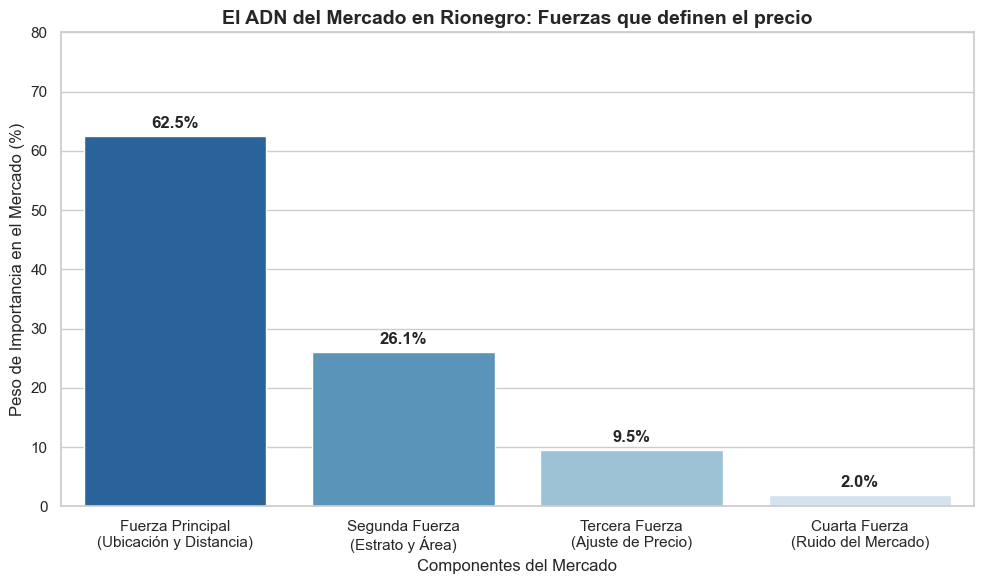

In [27]:
# GRÁFICA 1: "FUERZAS DEL MERCADO" (Eigenvalores traducidos a porcentajes)
# Calculamos los porcentajes dinámicamente desde nuestros eigenvalores
porcentajes = [(val / sum(eigenvalores_ord)) * 100 for val in eigenvalores_ord]

fuerzas = [
    "Fuerza Principal\n(Ubicación y Distancia)", 
    "Segunda Fuerza\n(Estrato y Área)", 
    "Tercera Fuerza\n(Ajuste de Precio)", 
    "Cuarta Fuerza\n(Ruido del Mercado)"
]

plt.figure(figsize=(10, 6))
barras = sns.barplot(x=fuerzas, y=porcentajes, palette="Blues_r")

# Añadir los porcentajes encima de las barras
for p in barras.patches:
    barras.annotate(f'{p.get_height():.1f}%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')

plt.title("El ADN del Mercado en Rionegro: Fuerzas que definen el precio", fontsize=14, fontweight='bold')
plt.ylabel("Peso de Importancia en el Mercado (%)", fontsize=12)
plt.xlabel("Componentes del Mercado", fontsize=12)
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

**Interpretación para Inversionistas:**

Esta gráfica revela el secreto del mercado inmobiliario de Rionegro, con casi un 63% de una sola fuerza que sería la ubicación o distancia al CC San Nicolás como punto central de nuestro estudio realizado. Es decir, la verdadera clave que define el éxito del negocio está en elegir una ubicación que esté cerca a un area comercial, mientras si la firma de inversión se decide alejar, las zonas campestres abre una oportunidad con altos rangos de ganancia. Nuestro concejo sería que no se desgasten negociando proyectos con pocos metros cuadrados o acabados, invertir cerca de un área comercial garantiza ventas rápidas y rentabilidad segura, mientras que si ellos se deciden alejar a zonas campestres y a tener alto presupuesto para invertir, esas casas generan mucho más valor en una sola venta, aunque la venta se puede demorar por su precio.

---
Grafica 2:

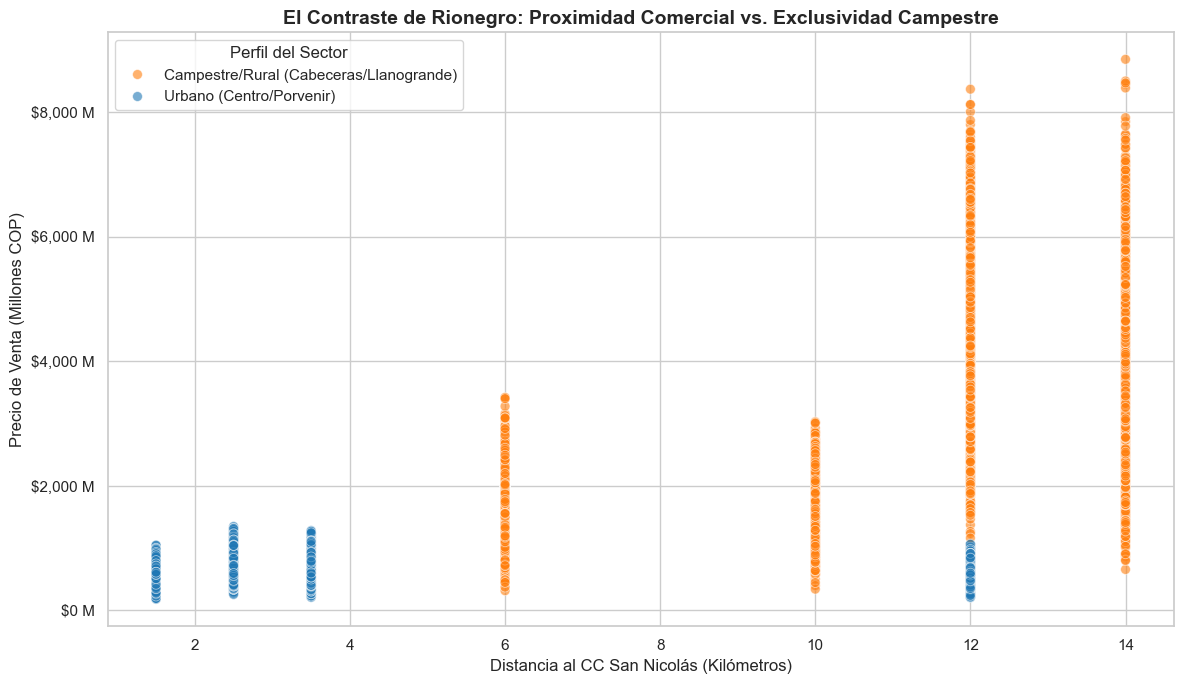

In [25]:
# GRÁFICA 2: DE DISPERSIÓN (DISTANCIA VS PRECIO COLOREADO POR TIPO)
plt.figure(figsize=(12, 7))

# Mapeamos los números a texto para la leyenda usando la columna original 'Urbana_Rural_Num'
df['Tipo_Zona'] = df['Urbana_Rural_Num'].map({1: 'Urbano (Centro/Porvenir)', 0: 'Campestre/Rural (Cabeceras/Llanogrande)'})

sns.scatterplot(data=df, x='Distancia_CC_SanNicolas_km', y='Precio_Venta_COP', 
                hue='Tipo_Zona', palette=['#ff7f0e', '#1f77b4'], alpha=0.6, s=50)

# Formatear el eje Y para que muestre "Millones" de forma más limpia
formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:,.0f} M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("El Contraste de Rionegro: Proximidad Comercial vs. Exclusividad Campestre", fontsize=14, fontweight='bold')
plt.xlabel("Distancia al CC San Nicolás (Kilómetros)", fontsize=12)
plt.ylabel("Precio de Venta (Millones COP)", fontsize=12)
plt.legend(title="Perfil del Sector")
plt.tight_layout()
plt.show()

**Interpretación para Inversionistas:**

Lo que nos quiere decir la gráfica es que tenemos 2 clases de mercados en Rionegro donde la firma elige cuál le conviene mejor, si ellos se quieren ir por un lado seguro, donde se realicen ventas rápidas y su mercado sea predecible, el secreto está en invertir en propiedades cerca al CC San Nicolás, por su corta distancia con él, mientras si se quieren ir por el lado de presupuestos muy altos, de casas de altísimo valor, esta las zonas. campestres donde una casa puede valer el doble o triple dependiendo del terreno y acabados que esta tenga, pero es un mercado donde se realizan menos ventas y su mercado es demasiado lento, pero haciendo una sola venta sus ganancias son millonarias.

---
Grafica 3:

/var/folders/fj/2jncwnhn17n1yn7455g_fgm00000gp/T/ipykernel_21900/2233561029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='Sector', x='Precio_Venta_COP', order=orden_sectores, palette="viridis")


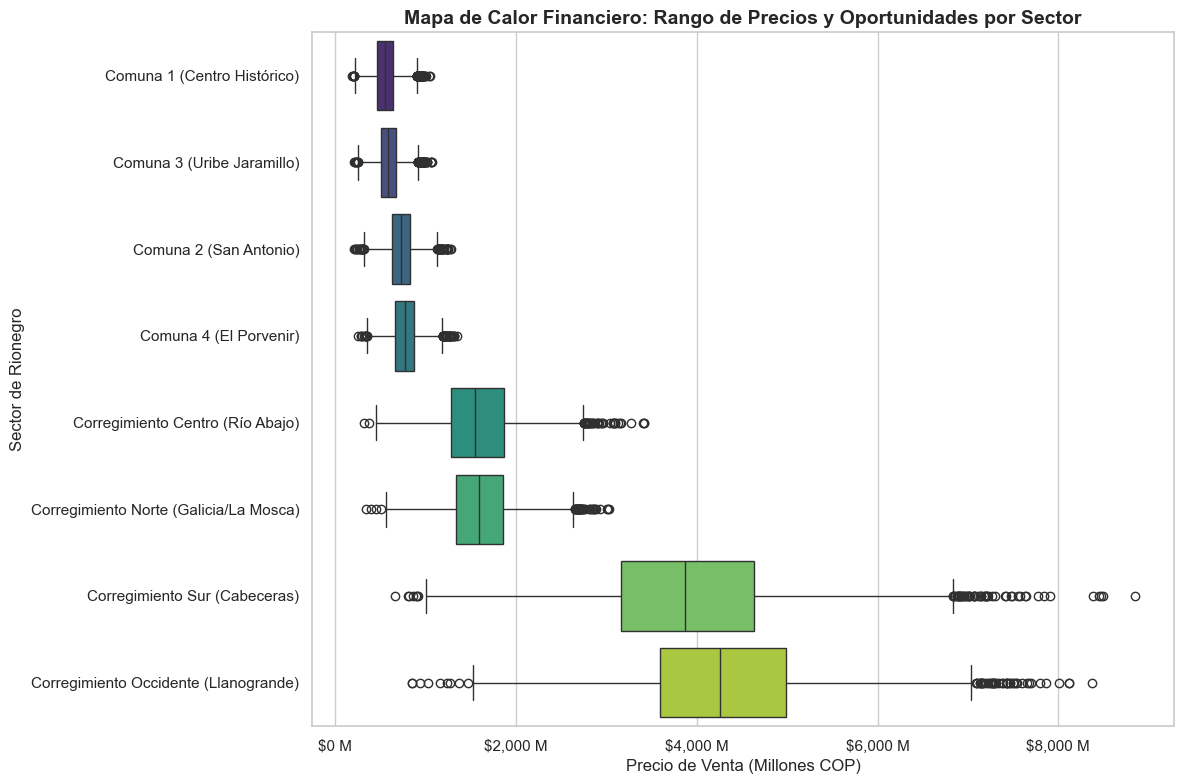

In [26]:
# GRÁFICA 3: DE CAJAS (BOXPLOT) - RIESGO Y VALOR POR SECTOR
plt.figure(figsize=(12, 8))

# Ordenar los sectores por precio mediano para que la gráfica tenga sentido progresivo de más barato a más caro
orden_sectores = df.groupby('Sector')['Precio_Venta_COP'].median().sort_values().index

sns.boxplot(data=df, y='Sector', x='Precio_Venta_COP', order=orden_sectores, palette="viridis")

# Formatear el eje X para que muestre "Millones"
plt.gca().xaxis.set_major_formatter(formatter)

plt.title("Mapa de Calor Financiero: Rango de Precios y Oportunidades por Sector", fontsize=14, fontweight='bold')
plt.xlabel("Precio de Venta (Millones COP)", fontsize=12)
plt.ylabel("Sector de Rionegro", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretación para inversionistas:**

Esta gráfica para alguien que quiera invertir en el sector inmobiliario de Rionegro le dice mucho, primero que todo tenemos arriba cajas que son estrechas, donde abarcan sectores como el centro histórico, San Antonio, El Porvenir, donde su significado es que estas casas no varían tanto de precio, su precio es casi similar, no es igual, pero si se acercan para parecerse, si ellos quieren tener alta rotación, vendiendo y comprando a la vez de forma segura, estos sectores son clave para invertir, mientras si nos vamos para los lados de abajo como sectores como lo son Llanogrande, Cabeceras, donde las cajas son anchas, nos quieren decir que este mercado es costoso y de alto riesgo, donde sus precios no tienen un tope fijo, sino que sobresalen. Pero si una firma de inversión es inteligente, puede jugar con la exclusividad que tienen estos sectores, como su privacidad, tamaño del lote, y jugar mucho con la exclusividad de la arquitectura, es una excusa para poder vender una casa con alto valor que si la logran vender pueden generar millones de ganancias con una sola venta.